### Import des librairies

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf



from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import keras_tuner as kt
import platform
from tensorflow.keras import backend as K

#import locaux

from import_dataset import load_dataset
from explore_data import downsample_data, plot_xy_grid, plot_3d, txt_to_df
from Edit_distance import edit_distance
from functions_nb import load_domain4_dataset, standardize_group, count_gestures




In [ ]:
X_d1, y_d1, subjects_d1, repetitions_d1 = prepare_sequences_for_deep_learning(df_domain1)
X_d1_d, y_d1_d, subjects_d1_d, repetitions_d1_d = prepare_sequences_for_deep_learning(df_domain1_downsampled)

X_d4, y_d4, subjects_d4, repetitions_d4 = prepare_sequences_for_deep_learning(df_domain4)
X_d4_d, y_d4_d, subjects_d4_d, repetitions_d4_d = prepare_sequences_for_deep_learning(df_domain4_downsampled)

print("Domain1")
print_X_seq_y_labels(X_d1,y_d1)

print("Domain1 downsampled")
print_X_seq_y_labels(X_d1_d,y_d1_d)

print("Domain4")
print_X_seq_y_labels(X_d4,y_d4)

print("Domain4 downsampled")
print_X_seq_y_labels(X_d4_d,y_d4_d)



In [5]:
print(tf.config.list_physical_devices('GPU'))

print(tf.__version__)
print(tf.test.is_built_with_cuda())

[]
2.15.0
False


# Import data & preprocessing

In [6]:
BASE_DIR = os.getcwd()

DATA_DIR_DOMAIN1 = os.path.join(BASE_DIR, "Dataset", "Domain1_csv")

dataset_domain1 = pd.concat(load_dataset(DATA_DIR_DOMAIN1), ignore_index=True)

df_domain1 = dataset_domain1.copy()

print("Domain 1 chargé.")
print(df_domain1.shape)
print(df_domain1.head())

Domain 1 chargé.
(85095, 7)
          x         y         z      t  subject_id  digit  repetition
0  0.042075  0.036799  0.258380    6.0           1      0           1
1  0.041904  0.037187  0.258505   37.0           1      0           1
2  0.041739  0.037219  0.258619   67.0           1      0           1
3  0.041446  0.037573  0.258731  101.0           1      0           1
4  0.041303  0.037331  0.258830  132.0           1      0           1


In [7]:
df_domain1_downsampled = (
    df_domain1.groupby(['subject_id', 'digit', 'repetition'], group_keys=False)
    .apply(downsample_data)
    .reset_index(drop=True)
)

'''
df_domain4_downsampled = (
    df_domain1_downsampled.groupby(['subject_id', 'digit', 'repetition'], group_keys=False)
    .apply(standardize_group)
    .reset_index(drop=True)
)
'''

print("Downsampling + standardisation terminés.")
print("Nombre de gestes :", count_gestures(df_domain1_downsampled))
print(df_domain1_downsampled.head())

Downsampling + standardisation terminés.
Nombre de gestes : 1000
          x         y         z      t  subject_id  digit  repetition
0  0.042075  0.036799  0.258380    6.0           1      0           1
1  0.041739  0.037219  0.258619   67.0           1      0           1
2  0.041303  0.037331  0.258830  132.0           1      0           1
3  0.039765  0.038245  0.259025  214.0           1      0           1
4  0.037329  0.038885  0.259251  277.0           1      0           1


In [8]:
def prepare_sequences_for_deep_learning(df):
    X_sequences = []
    y_labels = []
    subjects = []
    repetitions = []

    for (subject_id, digit, repetition), group in df.groupby(['subject_id', 'digit', 'repetition']):
        group = group.sort_values('t')

        sequence = group[['x_std', 'y_std', 'z_std']].values.astype('float32')

        X_sequences.append(sequence)
        y_labels.append(digit)
        subjects.append(subject_id)
        repetitions.append(repetition)

    return X_sequences, np.array(y_labels), np.array(subjects), np.array(repetitions)

X_sequences, y_labels, subjects, repetitions = prepare_sequences_for_deep_learning(df_domain1_downsampled)

print("Nombre de séquences :", len(X_sequences))
print("Shape d'une séquence :", X_sequences[0].shape)
print("Classes :", sorted(np.unique(y_labels)))

KeyError: "None of [Index(['x_std', 'y_std', 'z_std'], dtype='object')] are in the [columns]"

In [9]:
max_len = max(len(seq) for seq in X_sequences)

num_classes = 10

X_padded = pad_sequences(
    X_sequences,
    maxlen=max_len,
    dtype='float32',
    padding='post',
    truncating='post',
    value=0.0
)

print("Longueur maximale :", max_len)
print("Shape X_padded :", X_padded.shape)

Longueur maximale : 121
Shape X_padded : (1000, 121, 3)


In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

y_categorical = to_categorical(y_encoded)

print("Classes originales :", label_encoder.classes_)
print("Shape y :", y_categorical.shape)

Classes originales : [0 1 2 3 4 5 6 7 8 9]
Shape y : (1000, 10)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (800, 121, 3)
X_test : (200, 121, 3)
y_train : (800, 10)
y_test : (200, 10)


# Model implementation

In [12]:
num_classes = y_categorical.shape[1]

model_lstm = Sequential([
    Masking(mask_value=0.0, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

c:\Users\lechef\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 121, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,818 (77.41 KB)

 Trainable params: 19,818 (77.41 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.1795 - loss: 2.2593 - val_accuracy: 0.3313 - val_loss: 2.0467
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3511 - loss: 1.9939 - val_accuracy: 0.4125 - val_loss: 1.6814
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4555 - loss: 1.6274 - val_accuracy: 0.6125 - val_loss: 1.2251
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.5359 - loss: 1.2203 - val_accuracy: 0.6687 - val_loss: 0.9443
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.7085 - loss: 0.9098 - val_accuracy: 0.7000 - val_loss: 0.7450
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.7695 - loss: 0.7675 - val_accuracy: 0.8062 - val_loss: 0.5682
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8602 - loss: 0.5274 - val_accuracy: 0.8438 - val_loss: 0.4571
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8942 - loss: 0.4182 - val_accuracy: 

In [14]:
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)

print(f"LSTM test accuracy: {acc_lstm:.4f} ({acc_lstm*100:.2f}%)")

LSTM test accuracy: 0.9750 (97.50%)


In [15]:
model_gru = Sequential([
    Masking(mask_value=0.0, input_shape=(X_train.shape[1], X_train.shape[2])),
    GRU(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_gru.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 121, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,658 (61.16 KB)

 Trainable params: 15,658 (61.16 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_gru = model_gru.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 624ms/step - accuracy: 0.1494 - loss: 2.2444 - val_accuracy: 0.3000 - val_loss: 2.0522
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.2539 - loss: 2.0293 - val_accuracy: 0.3125 - val_loss: 1.7785
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2982 - loss: 1.7683 - val_accuracy: 0.3750 - val_loss: 1.5381
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3918 - loss: 1.5274 - val_accuracy: 0.5063 - val_loss: 1.2609
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5970 - loss: 1.2049 - val_accuracy: 0.6625 - val_loss: 0.9647
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6265 - loss: 0.9549 - val_accuracy: 0.7125 - val_loss: 0.8121
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7173 - loss: 0.7685 - val_accuracy: 0.7563 - val_loss: 0.6875
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.7488 - loss: 0.7278 - val_accuracy: 

In [17]:
loss_gru, acc_gru = model_gru.evaluate(X_test, y_test, verbose=0)

print(f"GRU test accuracy: {acc_gru:.4f} ({acc_gru*100:.2f}%)")

GRU test accuracy: 0.9800 (98.00%)


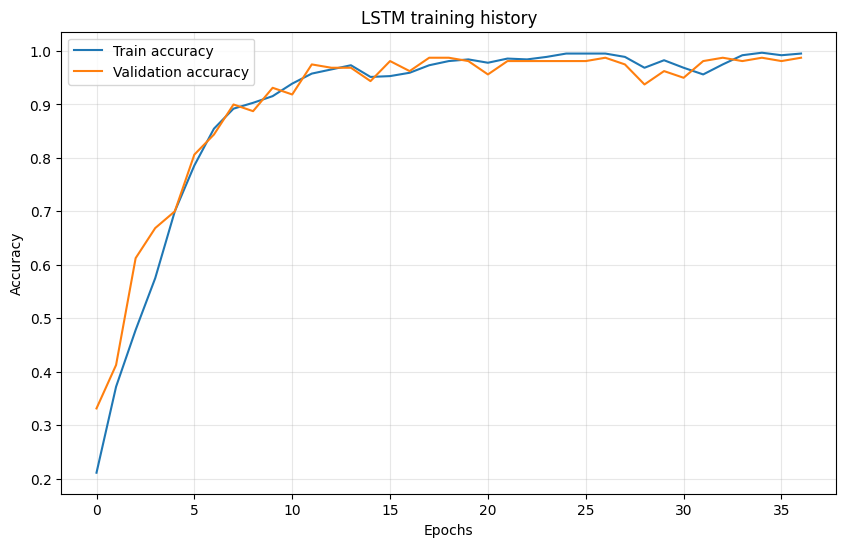

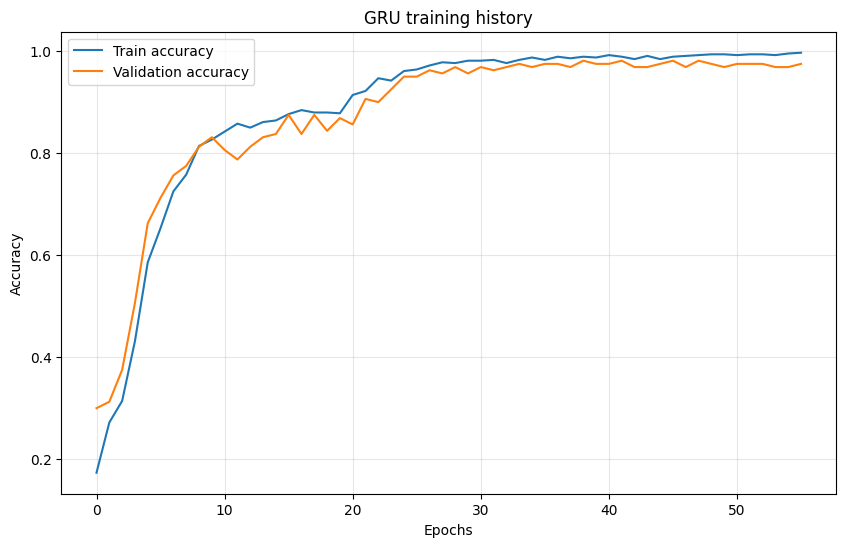

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['accuracy'], label='Train accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('LSTM training history')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_gru.history['accuracy'], label='Train accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('GRU training history')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step


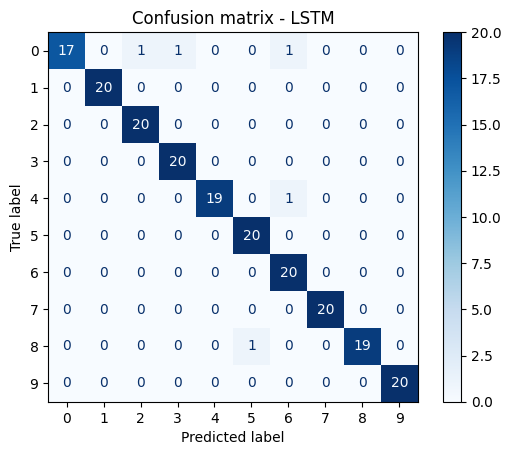

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step


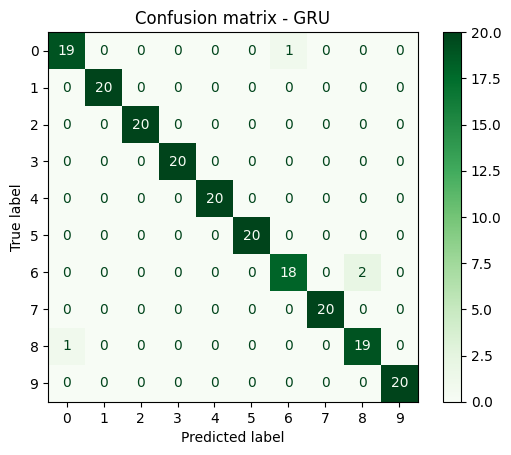

In [19]:
y_pred_lstm_proba = model_lstm.predict(X_test)
y_pred_lstm = np.argmax(y_pred_lstm_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

cm_lstm = confusion_matrix(y_true, y_pred_lstm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix - LSTM")
plt.show()


y_pred_gru_proba = model_gru.predict(X_test)
y_pred_gru = np.argmax(y_pred_gru_proba, axis=1)

cm_gru = confusion_matrix(y_true, y_pred_gru)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=label_encoder.classes_
)

disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion matrix - GRU")
plt.show()

# Double cross-validation to evaluate hyperparameters

In [ ]:
def build_tuned_rnn_model(hp):
    model = Sequential()
    
    # Couche de Masking obligatoire pour les séquences de tailles variables 

    # néglige les zéros de remplissage pour éviter de laisser croire que la personne était immobile

    model.add(Masking(mask_value=0.0, input_shape=(max_len, 3)))
    
    # HYPERPARAMÈTRES À TESTER
    num_layers = hp.Int('num_layers', min_value=1, max_value=3, step=1) # Profondeur
    units = hp.Choice('units', [32, 64, 128])                           # Neurones
    dropout = hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1) # dropout taux de neurone inactif volontairement pour désactiver des neurones bon et faire travailler les autres (coupe connexions entre couches)
    rec_dropout = hp.Float('recurrent_dropout', min_value=0.0, max_value=0.4, step=0.2) # recurrent dropout spécifique au RNN (coupe connexions temporelle entre t et t+1)
    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])                 # Learning Rate (abilité à modifier rapidement les poids si trop haut fait fortement varier si bon ou mauvais, si trop faible reste bloqué et nécessite beaucoup temps d'apprentissage)
    
    # Construction dynamique des couches cachées
    for i in range(num_layers):
        return_seq = (i < num_layers - 1) # True si ce n'est pas la dernière couche RNN
        
        model.add(LSTM(units=units, return_sequences=return_seq, recurrent_dropout=rec_dropout))
        
        #--- ci on veut tester meilleur cas entre LSTM et GRU
        
        #if rnn_type == 'LSTM':
        #    model.add(LSTM(units=units, return_sequences=return_seq, recurrent_dropout=rec_dropout))
        #else:
        #    model.add(GRU(units=units, return_sequences=return_seq, recurrent_dropout=rec_dropout))
            
        model.add(Dropout(dropout))
        
    # Couche de classification finale
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
        run_eagerly=False
    )
    
    return model

In [31]:
def split_subjects(subjects, val_ratio=0.2):
    unique = np.unique(subjects)
    np.random.shuffle(unique)

    n_val = int(len(unique) * val_ratio)
    val_subjects = unique[:n_val]

    train_subjects = unique[n_val:]

    return train_subjects, val_subjects

## User-Independent

In [33]:
def nested_cv_user_independent_numpy(X_padded, y_categorical, subjects, repetitions):
    csv_results = []
    
    unique_users = np.unique(subjects)
    
    # --- CORRECTION DÉFINITIVE DU CHEMIN ---
    # os.path.expanduser("~") te renvoie ton dossier utilisateur 
    # C'est garanti sans problème de droits d'admin et sans accents !
    home_dir = os.path.expanduser("~")
    safe_tuner_dir = os.path.join(home_dir, "temp_tuner_results")
    print(f"KerasTuner va sauvegarder ses fichiers temporaires dans : {safe_tuner_dir}")
    # ---------------------------------------

    for test_user in unique_users: # gestion outer loop (Leave-On-Out pour le Test)
        print(f"\n{'='*50}\nOuter Fold - Test sur le Sujet {test_user}\n{'='*50}")
        
        # 1. MASQUES NUMPY (Découpage instantané)
        test_mask = (subjects == test_user)
        train_mask = (subjects != test_user)
        
        X_train_cv = X_padded[train_mask]
        y_train_cv = y_categorical[train_mask]
        
        X_test_cv = X_padded[test_mask]
        y_test_cv = y_categorical[test_mask]
        
        # On garde les répétitions du test pour le fichier CSV
        test_repetitions = repetitions[test_mask]
        
        # 2. LE LABORATOIRE : Initialisation de KerasTuner
        tuner = kt.RandomSearch(
            build_tuned_rnn_model, # Ta fonction avec les hyperparamètres
            objective='val_accuracy',
            max_trials=5, # Nombre d'essais (à ajuster selon ton temps)
            directory=safe_tuner_dir,
            project_name=f'user_indep_fold_sujet_{test_user}',
            overwrite=True
        )
        
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        
        # 3. RECHERCHE (Inner CV via validation_split) 
        # Gestion inner loop à faire sur les 9 sujets restants mais la validation doit être fait sur un sujets séparés
        print("--- Début de la recherche d'hyperparamètres ---")


        train_subj, val_subj = split_subjects(subjects[train_mask], val_ratio=0.2)

        inner_train_mask = np.isin(subjects, train_subj) & train_mask
        inner_val_mask = np.isin(subjects, val_subj) & train_mask

        tuner.search( # tuner doit être appliqué sur un inner_training
            X_padded[inner_train_mask],
            y_categorical[inner_train_mask],
            validation_data=(X_padded[inner_val_mask], y_categorical[inner_val_mask]),
            epochs=30,
            callbacks=[early_stop],
            verbose=0
        )
        
        # 4. L'ÉLECTION : Récupération du meilleur modèle
        best_model = tuner.get_best_models(num_models=1)[0]
        
        # Récupération des meilleurs hyperparamètres
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        
        # Extraction des valeurs spécifiques
        hp_layers = best_hps.get('num_layers')
        hp_units = best_hps.get('units')
        hp_dropout = best_hps.get('dropout')
        hp_rec_dropout = best_hps.get('recurrent_dropout')
        hp_lr = best_hps.get('learning_rate')
        
        #  Affichage dans la console
        print(f"\n>>> Meilleurs Hyperparamètres trouvés pour exclure le Sujet {test_user} :")
        print(f"    - Couches: {hp_layers} | Neurones: {hp_units}")
        print(f"    - Dropout: {hp_dropout:.1f} | Recurrent Dropout: {hp_rec_dropout:.1f}")
        print(f"    - Learning Rate: {hp_lr}")
        print("-" * 50)

        # 5. L'EXAMEN FINAL : Prédictions
        predictions_proba = best_model.predict(X_test_cv, verbose=0)
        predictions = np.argmax(predictions_proba, axis=1) # Repasse de probabilités à Chiffre (0-9)
        true_labels = np.argmax(y_test_cv, axis=1)         # Pareil pour les vrais labels
        
        # 6. ENREGISTREMENT POUR LE CSV
        for i in range(len(predictions)):
            true_label = true_labels[i]
            pred_label = predictions[i]
            
            csv_results.append({
                'subject_id': test_user,
                'repetition': test_repetitions[i],
                'true_digit': true_label,
                'predicted_digit': pred_label,
                'is_correct': int(true_label == pred_label),
                'hp_num_layers': hp_layers,
                'hp_units': hp_units,
                'hp_dropout': hp_dropout,
                'hp_recurrent_dropout': hp_rec_dropout,
                'hp_learning_rate': hp_lr
            })
            
        # Calcul de l'accuracy pour ce sujet
        fold_acc = np.mean([1 if res['is_correct'] else 0 for res in csv_results if res['subject_id'] == test_user])
        print(f"Accuracy sur Sujet {test_user}: {fold_acc*100:.2f}%")

        K.clear_session()

    # Bilan final et Export CSV
    df_results = pd.DataFrame(csv_results)
    overall_acc = df_results['is_correct'].mean()
    
    print(f"\nAccuracy Globale (User-Independent): {overall_acc*100:.2f}%")
    df_results.to_csv('resultats_statistiques_user_indep_domain1_downsampled.csv', index=False)
    print("Résultats détaillés sauvegardés dans 'resultats_statistiques_user_indep.csv'")
    
    return df_results

In [10]:
df_result = nested_cv_user_independent_numpy(X_padded,y_categorical,subjects,repetitions)

NameError: name 'nested_cv_user_independent_numpy' is not defined

## User-Dependent

In [ ]:
# Tes répétitions vont probablement de 1 à 10
for fold_rep in np.unique(repetitions):
    print(f"\n--- Fold Répétition n°{fold_rep} ---")
    
    # Création des masques
    test_mask = (repetitions == fold_rep)
    train_mask = (repetitions != fold_rep)
    
    # Découpage instantané des Tenseurs
    X_train_cv = X_padded[train_mask]
    y_train_cv = y_categorical[train_mask]
    
    X_test_cv = X_padded[test_mask]
    y_test_cv = y_categorical[test_mask]
    
    # -> C'est ici que tu lances ton KerasTuner ou ton entraînement !
    # tuner.search(X_train_cv, y_train_cv, ...)